# Introduction

In this notebook, we are going to cover the definition and identification of heatwaves and their severity classes. To do this, we are going to fetch hourly temperature data of Adelaide on *1958-2024* interval. And use Australia's definition of heatwaves and severity classes. Contents of this notebook:
1. Short Explanation of Methodology
2. Data Acquisition and Quality Control
3. Derivation of Heatwave Indices and Identification of Heatwaves
4. Derivation of Severity Index and Severity Classes 
5. References

# Short Explanation of Methodology

This notebook follows the heatwave definition and methodology developed by the Australian Bureau of Meteorology and CSIRO: Commonwealth Scientific and Industrial Research Organisation, based on the Excess Heat Factor (EHF) framework. Heatwaves are identified by comparing short-term and long-term temperature anomalies, rather than using fixed temperature thresholds.

First, hourly temperature observations are converted into daily mean temperatures (DMT), where each day is defined from 9 am to the following 9 am (local time). The DMT is calculated as the average of the daily maximum and minimum temperatures over this period.

Using a long-term reference period, a climatological threshold ($T_{95}$) is computed as the 95th percentile of daily mean temperatures. Heat stress is then evaluated using two components:
- $EHI_{sig}$, which measures whether a three-day period is unusually hot compared to the long-term climate.
- $EHI_{accl}$, which measures whether recent temperatures are high relative to the previous 30 days, capturing short-term acclimatisation effects.

These components are combined into the **Excess Heat Factor (EHF)**, which determines whether a heatwave is occurring. Positive EHF values indicate heatwave conditions. Finally, heatwave severity is classified using a normalized severity index based on the distribution of historical EHF values, allowing events to be categorized as *low-intensity*, *severe*, or *extreme*.

All indices and thresholds are derived directly from the temperature data following operational methods, ensuring consistency with official Australian heatwave assessments.




# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from src.plotting_utils import plot_time_slice, plot_with_time_range
from src.data_utils import fetch_hourly_weather_range

# Data Acquisition and Quality Control

Hourly temperature data for Adelaide were used in this analysis, covering the period from 1958 to 2024. All timestamps are handled in local time (Australia/Adelaide) to ensure consistency with the operational 9 am–to–9 am definition of meteorological days used in Australian heatwave studies.

Basic quality checks were applied to ensure continuity and completeness of the temperature record. Or in case of any sensor issue.

The processed temperature data are then used to derive daily temperature metrics and heatwave indices following the established Australian Excess Heat Factor framework.


## Acquisition

In [20]:
HOURLY_VARS = ["temperature_2m"]

In [2]:
df_1 = fetch_hourly_weather_range(
    start_year=1958,
    end_year=1970,
    hourly_vars=HOURLY_VARS,
    save_path=None
)
df_1.info()

Fetching 1958-01-01 → 1958-06-30 ...
Success: 1958-01-01 → 1958-06-30 (4344 rows)
Fetching 1958-07-01 → 1958-12-31 ...
Success: 1958-07-01 → 1958-12-31 (4416 rows)
Fetching 1959-01-01 → 1959-06-30 ...
Success: 1959-01-01 → 1959-06-30 (4344 rows)
Fetching 1959-07-01 → 1959-12-31 ...
Success: 1959-07-01 → 1959-12-31 (4416 rows)
Fetching 1960-01-01 → 1960-06-30 ...
Success: 1960-01-01 → 1960-06-30 (4368 rows)
Fetching 1960-07-01 → 1960-12-31 ...
Success: 1960-07-01 → 1960-12-31 (4416 rows)
Fetching 1961-01-01 → 1961-06-30 ...
Success: 1961-01-01 → 1961-06-30 (4344 rows)
Fetching 1961-07-01 → 1961-12-31 ...
Success: 1961-07-01 → 1961-12-31 (4416 rows)
Fetching 1962-01-01 → 1962-06-30 ...
Success: 1962-01-01 → 1962-06-30 (4344 rows)
Fetching 1962-07-01 → 1962-12-31 ...
Success: 1962-07-01 → 1962-12-31 (4416 rows)
Fetching 1963-01-01 → 1963-06-30 ...
Success: 1963-01-01 → 1963-06-30 (4344 rows)
Fetching 1963-07-01 → 1963-12-31 ...
Success: 1963-07-01 → 1963-12-31 (4416 rows)
Fetching 1964-01

In [3]:
df_1.to_csv("data/raw/adelaide_temp_1958_1970.csv")

In [4]:
df_2 = fetch_hourly_weather_range(
    start_year=1971,
    end_year=2003,
    hourly_vars=HOURLY_VARS,
    save_path=None
)

Fetching 1971-01-01 → 1971-06-30 ...
Success: 1971-01-01 → 1971-06-30 (4344 rows)
Fetching 1971-07-01 → 1971-12-31 ...
Success: 1971-07-01 → 1971-12-31 (4416 rows)
Fetching 1972-01-01 → 1972-06-30 ...
Success: 1972-01-01 → 1972-06-30 (4368 rows)
Fetching 1972-07-01 → 1972-12-31 ...
Success: 1972-07-01 → 1972-12-31 (4416 rows)
Fetching 1973-01-01 → 1973-06-30 ...
Success: 1973-01-01 → 1973-06-30 (4344 rows)
Fetching 1973-07-01 → 1973-12-31 ...
Success: 1973-07-01 → 1973-12-31 (4416 rows)
Fetching 1974-01-01 → 1974-06-30 ...
Success: 1974-01-01 → 1974-06-30 (4344 rows)
Fetching 1974-07-01 → 1974-12-31 ...
Success: 1974-07-01 → 1974-12-31 (4416 rows)
Fetching 1975-01-01 → 1975-06-30 ...
Success: 1975-01-01 → 1975-06-30 (4344 rows)
Fetching 1975-07-01 → 1975-12-31 ...
Success: 1975-07-01 → 1975-12-31 (4416 rows)
Fetching 1976-01-01 → 1976-06-30 ...
Success: 1976-01-01 → 1976-06-30 (4368 rows)
Fetching 1976-07-01 → 1976-12-31 ...
Success: 1976-07-01 → 1976-12-31 (4416 rows)
Fetching 1977-01

In [5]:
df_2.to_csv("data/raw/adelaide_temp_1971_2003.csv")

## Merging

In [8]:
# Merge data
concat_df = pd.concat([df_1, df_2], axis=0)
concat_df.head()

,temperature_2m
datetime,
1957-12-31 13:30:00,14.390000
1957-12-31 14:30:00,14.240001
1957-12-31 15:30:00,14.390000
1957-12-31 16:30:00,14.440001
1957-12-31 17:30:00,14.490001


In [10]:
pd.Series(concat_df.index).nunique(), len(pd.date_range(start=concat_df.index.min(), end=concat_df.index.max(), freq="h"))

(403224, 403224)

Data has no missing or duplicate rows.

In [11]:
concat_df.index = concat_df.index.tz_localize("UTC")
print(concat_df.index.tz)

UTC


In [12]:
concat_df["datetime_local"] = concat_df.index.tz_convert("Australia/Adelaide")
concat_df.head()

,temperature_2m,datetime_local
datetime,,
1957-12-31 13:30:00+00:00,14.390000,1957-12-31 23:00:00+09:30
1957-12-31 14:30:00+00:00,14.240001,1958-01-01 00:00:00+09:30
1957-12-31 15:30:00+00:00,14.390000,1958-01-01 01:00:00+09:30
1957-12-31 16:30:00+00:00,14.440001,1958-01-01 02:00:00+09:30
1957-12-31 17:30:00+00:00,14.490001,1958-01-01 03:00:00+09:30


In [18]:
concat_df.index.rename("datetime_utc", inplace=True)

In [20]:
# Load previously fetched and processed data
adelaide_04_24_df = pd.read_csv(
    "data/processed/adelaide_hourly_weather.csv",
    parse_dates=["datetime_utc"],
    index_col="datetime_utc"
)
adelaide_04_24_df["datetime_local"] = adelaide_04_24_df.index.tz_convert("Australia/Adelaide")

In [ ]:
# Merging two data frame
temp_1958_2024_df = pd.concat([concat_df, adelaide_04_24_df[['temperature_2m', 'datetime_local']]], axis=0)
temp_1958_2024_df.head()

,temperature_2m,datetime_local
datetime_utc,,
1957-12-31 13:30:00+00:00,14.390000,1957-12-31 23:00:00+09:30
1957-12-31 14:30:00+00:00,14.240001,1958-01-01 00:00:00+09:30
1957-12-31 15:30:00+00:00,14.390000,1958-01-01 01:00:00+09:30
1957-12-31 16:30:00+00:00,14.440001,1958-01-01 02:00:00+09:30
1957-12-31 17:30:00+00:00,14.490001,1958-01-01 03:00:00+09:30


In [31]:
# Drop first row to start it exactly from local time at "1958-01-01 00:00:00+09:30".
temp_1958_2024_df = temp_1958_2024_df.iloc[1:] 
temp_1958_2024_df.head()

,temperature_2m,datetime_local
datetime_utc,,
1957-12-31 14:30:00+00:00,14.240001,1958-01-01 00:00:00+09:30
1957-12-31 15:30:00+00:00,14.390000,1958-01-01 01:00:00+09:30
1957-12-31 16:30:00+00:00,14.440001,1958-01-01 02:00:00+09:30
1957-12-31 17:30:00+00:00,14.490001,1958-01-01 03:00:00+09:30
1957-12-31 18:30:00+00:00,13.890000,1958-01-01 04:00:00+09:30


In [32]:
idx = temp_1958_2024_df.loc['2003-12-31': '2004-01-01'].index
len(pd.date_range(idx.min(), idx.max(), freq="h")), len(idx)

(48, 48)

In [33]:
pd.Series(idx)

0    2003-12-31 00:30:00+00:00
1    2003-12-31 01:30:00+00:00
2    2003-12-31 02:30:00+00:00
3    2003-12-31 03:30:00+00:00
4    2003-12-31 04:30:00+00:00
5    2003-12-31 05:30:00+00:00
6    2003-12-31 06:30:00+00:00
7    2003-12-31 07:30:00+00:00
8    2003-12-31 08:30:00+00:00
9    2003-12-31 09:30:00+00:00
10   2003-12-31 10:30:00+00:00
11   2003-12-31 11:30:00+00:00
12   2003-12-31 12:30:00+00:00
13   2003-12-31 13:30:00+00:00
14   2003-12-31 14:30:00+00:00
15   2003-12-31 15:30:00+00:00
16   2003-12-31 16:30:00+00:00
17   2003-12-31 17:30:00+00:00
18   2003-12-31 18:30:00+00:00
19   2003-12-31 19:30:00+00:00
20   2003-12-31 20:30:00+00:00
21   2003-12-31 21:30:00+00:00
22   2003-12-31 22:30:00+00:00
23   2003-12-31 23:30:00+00:00
24   2004-01-01 00:30:00+00:00
25   2004-01-01 01:30:00+00:00
26   2004-01-01 02:30:00+00:00
27   2004-01-01 03:30:00+00:00
28   2004-01-01 04:30:00+00:00
29   2004-01-01 05:30:00+00:00
30   2004-01-01 06:30:00+00:00
31   2004-01-01 07:30:00+00:00
32   200

Merging point has no missing or duplicate rows.

In [34]:
temp_1958_2024_df.to_csv("data/processed/adelaide_temp_1958_2024.csv", index=True, index_label="datetime_utc")

In [ ]:
temp_1958_2024_df = pd.read_csv("data/processed/adelaide_temp_1958_2024.csv", 
                                parse_dates=["datetime_utc"],
                                index_col="datetime_utc")
temp_1958_2024_df["datetime_local"] = temp_1958_2024_df.index.tz_convert("Australia/Adelaide")

## Quality Control

In [5]:
temp_1958_2024_df['temperature_2m'].describe()

count    587327.000000
mean         16.264380
std           5.984396
min           0.990000
25%          11.940001
50%          15.040000
75%          19.639999
max          42.737503
Name: temperature_2m, dtype: float64

In [ ]:
plot_with_time_range(temp_1958_2024_df, "temperature_2m", x_axis='datetime_local')

![image](plot_img/03_temperature_2m_1958_2024.png)

**!** Cell output is replaced with its image due to its size.

Not encountered with any possible sensor issues. Temperature range and plot seem reasonable.

# Derivation of Heatwave Indices and Identification of Heatwaves

## Daily Mean Temperature (DMT)

The core temperature variable used in all subsequent heatwave calculations is the **Daily Mean Temperature (DMT)**.  
Following the Australian Bureau of Meteorology definition, DMT is calculated as the average of the daily minimum and maximum temperatures:

$$
\text{DMT} = \frac{T_{\min} + T_{\max}}{2}
$$

Daily minimum and maximum temperatures are derived using a **9 am to 9 am** meteorological day.  
This means that for a given calendar day *i*, both $T_{\min}$ and $T_{\max}$ are taken from the 24-hour period spanning **9 am on day *i* to 9 am on day *i+1*** (local time). As a result, the daily minimum temperature may occur on the following calendar date, but it is still assigned to day *i*.

This definition ensures consistency with Australian operational climate practices and allows the derived heatwave indices to be directly comparable with official analyses.

In [ ]:
def compute_tmin_tmax_dmt(df: pd.DataFrame) -> pd.Series:
    """
    Compute Daily Mean Temperature (DMT) using 9am-9am definition
    and broadcast the same DMT to all hourly records of that day.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
        - 'temperature_2m'
        - 'datetime_local' (tz-aware, Australia/Adelaide)
        Index can be UTC or anything (not used for grouping)

    Returns
    -------
    pd.Series
        Hourly DMT values aligned to original dataframe index
    """

    data = df[['temperature_2m', 'datetime_local']].copy()

    # Shift local time by -9 hours so "day" starts at 00:00
    data['dmt_day'] = (data['datetime_local'] - pd.Timedelta(hours=9)).dt.floor('D')

    # Compute Tmin and Tmax per DMT-day
    daily_stats = (
        data.groupby('dmt_day')['temperature_2m']
        .agg(tmin='min', tmax='max')
    )

    # Compute DMT
    daily_stats['DMT'] = (daily_stats['tmin'] + daily_stats['tmax']) / 2
        
    # Shift back to normal calendar day (00:00 local). Look below for explanation.
    data['dmt_day'] = data['datetime_local'].dt.floor('D')

    # Join Tmin, Tmax and DMT
    tmin_tmax_dmt = (
        data[['dmt_day']]
        .join(daily_stats[['tmin', 'tmax', 'DMT']], on='dmt_day')
    )

    # Align index with original dataframe
    tmin_tmax_dmt.index = df.index

    return tmin_tmax_dmt

In [13]:
tmin_tmax_dmt = compute_tmin_tmax_dmt(temp_1958_2024_df)
tmin_tmax_dmt.head()

,dmt_day,tmin,tmax,DMT
datetime_utc,,,,
1957-12-31 14:30:00+00:00,1958-01-01 00:00:00+09:30,12.79,21.789999,17.289999
1957-12-31 15:30:00+00:00,1958-01-01 00:00:00+09:30,12.79,21.789999,17.289999
1957-12-31 16:30:00+00:00,1958-01-01 00:00:00+09:30,12.79,21.789999,17.289999
1957-12-31 17:30:00+00:00,1958-01-01 00:00:00+09:30,12.79,21.789999,17.289999
1957-12-31 18:30:00+00:00,1958-01-01 00:00:00+09:30,12.79,21.789999,17.289999


In [14]:
temp_1958_2024_df[['tmin', 'tmax', 'DMT']] = tmin_tmax_dmt[['tmin', 'tmax', 'DMT']]
temp_1958_2024_df.head(42)

,temperature_2m,datetime_local,DMT,tmin,tmax
datetime_utc,,,,,
1957-12-31 14:30:00+00:00,14.240001,1958-01-01 00:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 15:30:00+00:00,14.390000,1958-01-01 01:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 16:30:00+00:00,14.440001,1958-01-01 02:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 17:30:00+00:00,14.490001,1958-01-01 03:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 18:30:00+00:00,13.890000,1958-01-01 04:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 19:30:00+00:00,13.790000,1958-01-01 05:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 20:30:00+00:00,14.640000,1958-01-01 06:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 21:30:00+00:00,15.740001,1958-01-01 07:00:00+09:30,17.289999,12.790000,21.789999
1957-12-31 22:30:00+00:00,16.889999,1958-01-01 08:00:00+09:30,17.289999,12.790000,21.789999


In [15]:
# Manual calculation for comparison
t_1 = temp_1958_2024_df.iloc[9:33] # Local "1958-01-01 09:00:00+09:30" - "1958-01-02 08:00:00+09:30"
print('Max:', t_1['temperature_2m'].max(), 'Min:', t_1['temperature_2m'].min())
print('DMT:', (t_1['temperature_2m'].max() + t_1['temperature_2m'].min()) / 2) 
print(temp_1958_2024_df.loc[temp_1958_2024_df['datetime_local'].dt.floor('D')=='1958-01-01'][['tmin', 'tmax', 'DMT']].iloc[0])

Max: 21.78999900817871 Min: 12.789999961853027
DMT: 17.28999948501587
tmin    12.790000
tmax    21.789999
DMT     17.289999
Name: 1957-12-31 14:30:00+00:00, dtype: float64


**!** Why we shift back **DMT time** to 00:00:00 again?(in ``compute_tmin_tmax_dmt(df)``): In this way when we down sample the data to daily frequency, pandas is going to assign days' DMTs correctly. Let's give a little demonstration.

In [16]:
temp_1958_2024_df.set_index('datetime_local')[['tmin', 'tmax', 'DMT']].resample('D').mean().head(42)

,tmin,tmax,DMT
datetime_local,,,
1958-01-01 00:00:00+09:30,12.790000,21.789999,17.289999
1958-01-02 00:00:00+09:30,12.440001,22.889999,17.665000
1958-01-03 00:00:00+09:30,14.690001,24.740000,19.715000
1958-01-04 00:00:00+09:30,16.689999,29.539999,23.114999
1958-01-05 00:00:00+09:30,15.640000,31.039999,23.340000
1958-01-06 00:00:00+09:30,16.289999,29.889999,23.089999
1958-01-07 00:00:00+09:30,16.939999,30.139999,23.539999
1958-01-08 00:00:00+09:30,23.990000,32.989998,28.489999
1958-01-09 00:00:00+09:30,14.890000,35.639999,25.265000


When we compare this with original hourly `temp_1958_2024_df` `tmin, tmax, DMT` values, they match correctly.

In [18]:
temp_1958_2024_df.tail()

,temperature_2m,datetime_local,DMT,tmin,tmax
datetime_utc,,,,,
2024-12-31 08:30:00+00:00,24.287500,2024-12-31 19:00:00+10:30,22.412499,18.137499,26.6875
2024-12-31 09:30:00+00:00,23.687500,2024-12-31 20:00:00+10:30,22.412499,18.137499,26.6875
2024-12-31 10:30:00+00:00,20.937500,2024-12-31 21:00:00+10:30,22.412499,18.137499,26.6875
2024-12-31 11:30:00+00:00,19.187500,2024-12-31 22:00:00+10:30,22.412499,18.137499,26.6875
2024-12-31 12:30:00+00:00,18.137499,2024-12-31 23:00:00+10:30,22.412499,18.137499,26.6875


**!** According to our method, last day's (*2024-12-31*) `tmin, tmax, DMT` values are calculated wrong due to local *2025-01-01 00:00:00+10:30 -- 2025-01-01 08:00:00+10:30* date interval temperature values are missing. We are going to fetch this part and manually calculate and edit last days `DMT` value.

In [21]:
from src.data_utils import fetch_hourly_weather_data

df_25_first = fetch_hourly_weather_data(
    start_date='2025-01-01',
    end_date='2025-01-01',
    hourly_vars=HOURLY_VARS,
    save_path=None
)
df_25_first

,temperature_2m
datetime,
2024-12-31 13:30:00,17.187500
2024-12-31 14:30:00,16.537500
2024-12-31 15:30:00,16.137499
2024-12-31 16:30:00,15.887499
2024-12-31 17:30:00,15.737499
2024-12-31 18:30:00,15.637500
2024-12-31 19:30:00,15.537499
2024-12-31 20:30:00,16.437500
2024-12-31 21:30:00,17.987499


In [22]:
# Modify dates for convenience and simplification
df_25_first.index = df_25_first.index.tz_localize("UTC")
df_25_first.index.rename("datetime_utc", inplace=True)
df_25_first['datetime_local'] = df_25_first.index.tz_convert("Australia/Adelaide")
df_25_first

,temperature_2m,datetime_local
datetime_utc,,
2024-12-31 13:30:00+00:00,17.187500,2025-01-01 00:00:00+10:30
2024-12-31 14:30:00+00:00,16.537500,2025-01-01 01:00:00+10:30
2024-12-31 15:30:00+00:00,16.137499,2025-01-01 02:00:00+10:30
2024-12-31 16:30:00+00:00,15.887499,2025-01-01 03:00:00+10:30
2024-12-31 17:30:00+00:00,15.737499,2025-01-01 04:00:00+10:30
2024-12-31 18:30:00+00:00,15.637500,2025-01-01 05:00:00+10:30
2024-12-31 19:30:00+00:00,15.537499,2025-01-01 06:00:00+10:30
2024-12-31 20:30:00+00:00,16.437500,2025-01-01 07:00:00+10:30
2024-12-31 21:30:00+00:00,17.987499,2025-01-01 08:00:00+10:30


In [23]:
# Drop after 8am local and add temperature values from *2024-12-31 09:00:00+10:30* to *2025-01-01 00:00:00+10:30* to beginning.
df_25_first = df_25_first.loc[df_25_first['datetime_local'].dt.hour < 9]
df_24_end = temp_1958_2024_df.loc[temp_1958_2024_df['datetime_local'].dt.floor('D')=='2024-12-31', ['temperature_2m', 'datetime_local']].copy()
df_24_end = df_24_end.loc[df_24_end['datetime_local'].dt.hour >= 9]
df_25_first = pd.concat([df_24_end, df_25_first])
df_25_first

,temperature_2m,datetime_local
datetime_utc,,
2024-12-30 22:30:00+00:00,21.187500,2024-12-31 09:00:00+10:30
2024-12-30 23:30:00+00:00,22.837500,2024-12-31 10:00:00+10:30
2024-12-31 00:30:00+00:00,23.937500,2024-12-31 11:00:00+10:30
2024-12-31 01:30:00+00:00,25.387499,2024-12-31 12:00:00+10:30
2024-12-31 02:30:00+00:00,26.387499,2024-12-31 13:00:00+10:30
2024-12-31 03:30:00+00:00,26.687500,2024-12-31 14:00:00+10:30
2024-12-31 04:30:00+00:00,26.587500,2024-12-31 15:00:00+10:30
2024-12-31 05:30:00+00:00,26.587500,2024-12-31 16:00:00+10:30
2024-12-31 06:30:00+00:00,26.437500,2024-12-31 17:00:00+10:30


In [24]:
# Calculate and assign DMT to *2024-12-31* records.
max_temp, min_temp = df_25_first['temperature_2m'].max(), df_25_first['temperature_2m'].min()
dmt_12_31 = (max_temp + min_temp) / 2
temp_1958_2024_df.loc[temp_1958_2024_df['datetime_local'].dt.floor('D')=='2024-12-31', ['tmin', 'tmax', 'DMT']] = np.array([min_temp, max_temp, dmt_12_31])
temp_1958_2024_df.tail(30)

,temperature_2m,datetime_local,DMT,tmin,tmax
datetime_utc,,,,,
2024-12-30 07:30:00+00:00,25.637499,2024-12-30 18:00:00+10:30,21.037499,14.437500,27.637499
2024-12-30 08:30:00+00:00,23.387499,2024-12-30 19:00:00+10:30,21.037499,14.437500,27.637499
2024-12-30 09:30:00+00:00,22.537500,2024-12-30 20:00:00+10:30,21.037499,14.437500,27.637499
2024-12-30 10:30:00+00:00,21.887499,2024-12-30 21:00:00+10:30,21.037499,14.437500,27.637499
2024-12-30 11:30:00+00:00,20.287500,2024-12-30 22:00:00+10:30,21.037499,14.437500,27.637499
2024-12-30 12:30:00+00:00,19.037500,2024-12-30 23:00:00+10:30,21.037499,14.437500,27.637499
2024-12-30 13:30:00+00:00,18.287500,2024-12-31 00:00:00+10:30,21.112500,15.537499,26.687500
2024-12-30 14:30:00+00:00,17.537500,2024-12-31 01:00:00+10:30,21.112500,15.537499,26.687500
2024-12-30 15:30:00+00:00,16.687500,2024-12-31 02:00:00+10:30,21.112500,15.537499,26.687500


In [25]:
temp_1958_2024_df.to_csv("data/processed/adelaide_temp_1958_2024.csv", index=True, index_label="datetime_utc")

## Defining Long-term Threshold Temperature $T_{95}$

To identify unusually hot conditions relative to the local climate, a long-term threshold temperature $T_{95}$ is required.  
This threshold is defined as the **95th percentile of the DMT distribution** and represents extreme but climatologically meaningful temperature conditions.

In this study, $T_{95}$ is calculated using **only the 1971–2000 period**. This reference interval is commonly used in Australian climate studies and is chosen to:
- represent a relatively stable baseline climate,
- avoid inflating thresholds due to recent climate warming,
- maintain consistency with the original Excess Heat Factor (EHF) framework.

Using a fixed historical reference period allows heatwaves in more recent years to be evaluated relative to a well-defined “normal climate”, rather than a moving or warming baseline.

The calculated $T_{95}$ value is then used for calculation of long-term significant heatwave index $EHI_{sig}$.


In [26]:
# Daily mean temperatures
dmt_daily = temp_1958_2024_df.set_index('datetime_local')['DMT'].resample('D').mean()
dmt_daily.head()

datetime_local
1958-01-01 00:00:00+09:30    17.289999
1958-01-02 00:00:00+09:30    17.665000
1958-01-03 00:00:00+09:30    19.715000
1958-01-04 00:00:00+09:30    23.114999
1958-01-05 00:00:00+09:30    23.340000
Freq: D, Name: DMT, dtype: float64

In [27]:
dmt_daily.loc['1971-01-01':'2000-12-31']

datetime_local
1971-01-01 00:00:00+09:30    16.765
1971-01-02 00:00:00+09:30    17.390
1971-01-03 00:00:00+09:30    18.640
1971-01-04 00:00:00+09:30    20.765
1971-01-05 00:00:00+09:30    26.865
                              ...  
2000-12-27 00:00:00+10:30    15.540
2000-12-28 00:00:00+10:30    15.465
2000-12-29 00:00:00+10:30    19.715
2000-12-30 00:00:00+10:30    24.190
2000-12-31 00:00:00+10:30    25.690
Freq: D, Name: DMT, Length: 10958, dtype: float64

In [28]:
T_95 = dmt_daily.loc['1971-01-01':'2000-12-31'].quantile(0.95)  # 95th percentile of 1971-2000 DMT values
T_95

np.float64(26.293749761581413)

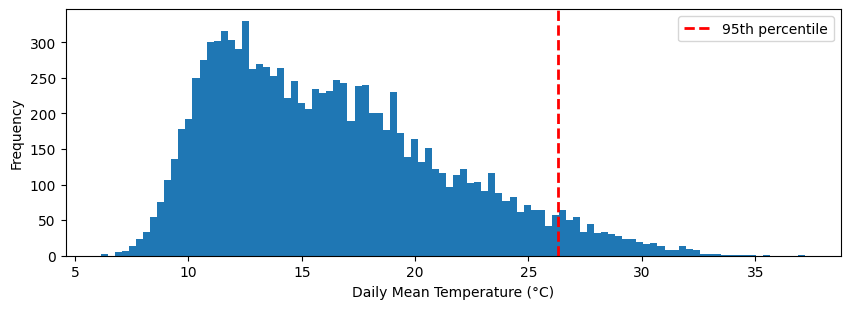

In [29]:
plt.figure(figsize=(10, 3.2))
plt.hist(dmt_daily.loc['1971-01-01':'2000-12-31'], bins=100)
plt.axvline(T_95, color='r', linestyle='dashed', linewidth=2, label='95th percentile')
plt.legend()
plt.xlabel("Daily Mean Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

We calculated `T_95` value and plotted it on histogram. We can see that 95th percentile is $26.29\degree\text{C}$ for Adelaide.

## Calculating Heatwave Indices and Factor

Heatwaves are identified using the **Excess Heat Factor (EHF)** framework, which combines both long-term and short-term temperature conditions.:

### Excess Heat Index – Significance $(EHI_{sig})$


The significance index measures how extreme the current temperatures are compared to the long-term climate:

$$
EHI_{sig} = \frac{T_{i}+T_{i+1}+T_{i+2}}{3}-T_{95}
$$

A positive $EHI_{sig}$ indicates that current temperatures exceed the long-term extreme threshold.

### Excess Heat Index – Acclimatisation $(EHI_{accl})$

The acclimatisation index captures how different the current heat is compared to recent conditions:

$$
EHI_{accl} =\frac{T_{i}+T_{i+1}+T_{i+2}}{3} - \frac{1}{30}\sum_{k=1}^{30} T_{i-k}
$$

This term captures short-term adaptation: the same heat feels more intense if it follows cooler days than if it comes after a long warm period.

Together, these indices ensure that a heatwave is not only unusually hot compared to the long-term climate, but also hot relative to recent conditions.

### Excess Heat Factor $(EHF)$

The final heatwave metric combines both indices:

$$
EHF = EHI_{sig} \times \max(1,\; EHI_{accl})
$$

A heatwave occurs when $EHF > 0$.  
This condition ensures that temperatures are both:
- extreme relative to the long-term climate, and
- sufficiently elevated compared to recent conditions.

**!** Thus the definition that *Australia The Bureau of Meterology* has provided: "A heatwave is when the maximum and minimum temperatures are unusually hot over 3 days. This is compared to the local climate and past weather."

In the following code cells these indices are calculated using daily mean temperatures (DMT).


In [42]:
def compute_ehi_ehf(dmt: pd.Series, T_95: float) -> pd.DataFrame:
    """
    Parameters
    ----------
    dmt : pd.Series
        Daily Mean Temperature series indexed by date (daily frequency).
    T_95 : float
        95th percentile temperature threshold.

    Returns
    -------
    pd.DataFrame
        Columns: ['EHI_sig', 'EHI_accl', 'EHF']
    """

    dmt_3day_forward = (
        dmt
        .rolling(window=3)
        .mean()
        .shift(-2)
    )
    EHI_sig = dmt_3day_forward - T_95

    past_30day_mean = dmt.shift(1).rolling(window=30).mean()
    EHI_accl = dmt_3day_forward - past_30day_mean

    EHF = EHI_sig * np.maximum(1, EHI_accl)

    return pd.DataFrame({
        'EHI_sig': EHI_sig,
        'EHI_accl': EHI_accl,
        'EHF': EHF
    })

In [43]:
ehi_ehf = compute_ehi_ehf(dmt_daily, T_95)
ehi_ehf.head()

,EHI_sig,EHI_accl,EHF
datetime_local,,,
1958-01-01 00:00:00+09:30,-8.070417,NaN,NaN
1958-01-02 00:00:00+09:30,-6.128750,NaN,NaN
1958-01-03 00:00:00+09:30,-4.237084,NaN,NaN
1958-01-04 00:00:00+09:30,-3.112084,NaN,NaN
1958-01-05 00:00:00+09:30,-2.970417,NaN,NaN


In [51]:
temp_1958_2024_df = temp_1958_2024_df.join(ehi_ehf, how='left')
temp_1958_2024_df[['EHI_sig', 'EHI_accl', 'EHF']] = temp_1958_2024_df[['EHI_sig', 'EHI_accl', 'EHF']].ffill()
temp_1958_2024_df.loc['1958-01-30':'1958-02-03', ['datetime_local', 'DMT', 'EHI_sig', 'EHI_accl', 'EHF']]

,datetime_local,DMT,EHI_sig,EHI_accl,EHF
datetime_utc,,,,,
1958-01-30 00:30:00+00:00,1958-01-30 10:00:00+09:30,20.014999,-7.170417,NaN,NaN
1958-01-30 01:30:00+00:00,1958-01-30 11:00:00+09:30,20.014999,-7.170417,NaN,NaN
1958-01-30 02:30:00+00:00,1958-01-30 12:00:00+09:30,20.014999,-7.170417,NaN,NaN
1958-01-30 03:30:00+00:00,1958-01-30 13:00:00+09:30,20.014999,-7.170417,NaN,NaN
1958-01-30 04:30:00+00:00,1958-01-30 14:00:00+09:30,20.014999,-7.170417,NaN,NaN
...,...,...,...,...,...
1958-02-03 19:30:00+00:00,1958-02-04 05:00:00+09:30,19.164999,-5.503750,-0.700834,-5.50375
1958-02-03 20:30:00+00:00,1958-02-04 06:00:00+09:30,19.164999,-5.503750,-0.700834,-5.50375
1958-02-03 21:30:00+00:00,1958-02-04 07:00:00+09:30,19.164999,-5.503750,-0.700834,-5.50375


$EHI_{accl}$ and $EHF$ values start at *"1958-01-31"* as they should be.

# Derivation of Severity Index and Severity Classes 

Not all heatwaves have the same real-world impact, so a severity measure is needed to distinguish between events that cause minor discomfort and those linked to serious health, mortality, and infrastructure effects.

The Excess Heat Factor (EHF) already combines both long-term climatic extremes and short-term acclimatisation effects. In the original CAWCR methodology, these two components are multiplied rather than added, as this formulation was found to relate more linearly to observed health impacts than an additive approach. This makes EHF a more meaningful indicator of real-world heat stress.

To further classify how severe a heatwave is relative to historical extremes, a severity index is derived from EHF.

## Defining $EHF_{85}$

The value $EHF_{85}$ is defined as the 85th percentile of all positive EHF values over a long historical reference period. This percentile represents a threshold beyond which heatwaves tend to be associated with significantly higher impacts. Using a percentile-based threshold also allows severity to be assessed relative to the local climate.

**! Note:** Normally they considered to use *Pareto distribution and principle* to calculate severity treshold in CAWCR methodology. However they've prefered to use emprical 85th percentile value as severity threshold due to a spesific interval sample (i.e. *1958-2024* for this study) does not represent population values correctly, thus using Pareto distribution would cause small errors. Also that's why they decided to keep a 5% error margin instead of directly using 80th percentile.

In [5]:
ehf_daily = temp_1958_2024_df.set_index('datetime_local')['EHF'].resample('D').mean()
ehf_pos = ehf_daily.dropna()
ehf_pos = ehf_pos[ehf_pos > 0]
EHF_85 = ehf_pos.quantile(0.85)
EHF_85

np.float64(28.116478278152794)

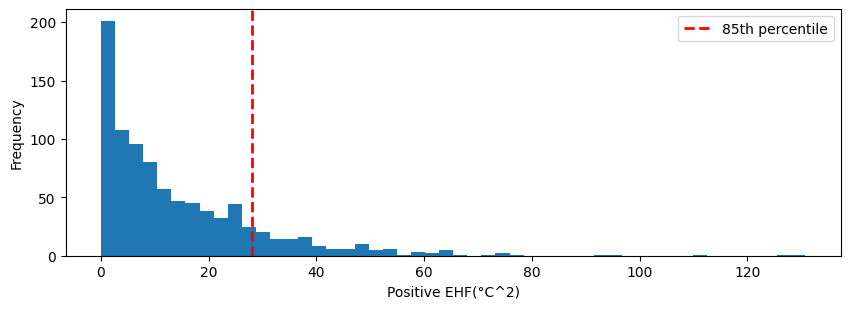

In [6]:
plt.figure(figsize=(10, 3.2))
plt.hist(ehf_pos, bins=50)
plt.axvline(EHF_85, color='r', linestyle='dashed', linewidth=2, label='85th percentile')
plt.legend()
plt.xlabel("Positive EHF(°C^2)")
plt.ylabel("Frequency")
plt.show()

We calculated $EHF_{85}$ as $28.12$ for *"1958-2024"* closed interval.

## Heatwave Severity Index and Severity Classes
The severity index is then calculated as:
$$
EHF_{sev} = \frac{EHF}{EHF_{85}}
$$

This normalises each heatwave day against historically severe events, making the index comparable across time.

Based on $EHF_{sev}$, each day is assigned to one of the following categories:

* No heatwave: $EHF_{sev} = 0$
* Low-intensity heatwave: $0 < EHF_{sev} < 1$
* Severe heatwave: $1 \leq EHF_{sev} < 3$
* Extreme heatwave: $EHF_{sev} \geq 3$

These classes provide a practical way to interpret heatwave impacts, linking meteorological conditions to potential effects on human health and built systems.

In [13]:
def compute_ehf_severity(ehf_daily: pd.Series, EHF_85: float) -> pd.DataFrame:
    """
    Computes EHF_sev and categorical heatwave severity from daily EHF series.
    """
    # Initialize EHF_sev
    ehf_sev = ehf_daily / EHF_85
    ehf_sev = ehf_sev.where(ehf_daily > 0, 0.0)  # EHF < 0 -> no heatwave
    ehf_sev = ehf_sev.astype(float)

    # Severity categories
    severity = pd.Series(index=ehf_daily.index, dtype="object")

    severity[ehf_sev == 0] = "No-heatwave"
    severity[(ehf_sev > 0) & (ehf_sev < 1)] = "Low-intensity"
    severity[(ehf_sev >= 1) & (ehf_sev < 3)] = "Severe"
    severity[ehf_sev >= 3] = "Extreme"

    # Preserve initial NaNs (e.g., first ~30 days)
    ehf_sev[ehf_daily.isna()] = np.nan
    severity[ehf_daily.isna()] = np.nan

    return pd.DataFrame({
        "EHF_sev": ehf_sev,
        "severity": severity
    })

In [16]:
severity_df = compute_ehf_severity(ehf_daily, EHF_85)
severity_df

,EHF_sev,severity
datetime_local,,
1958-01-01 00:00:00+09:30,NaN,NaN
1958-01-02 00:00:00+09:30,NaN,NaN
1958-01-03 00:00:00+09:30,NaN,NaN
1958-01-04 00:00:00+09:30,NaN,NaN
1958-01-05 00:00:00+09:30,NaN,NaN
...,...,...
2024-12-27 00:00:00+10:30,0.0,No-heatwave
2024-12-28 00:00:00+10:30,0.0,No-heatwave
2024-12-29 00:00:00+10:30,0.0,No-heatwave


In [23]:
temp_1958_2024_df = temp_1958_2024_df.join(severity_df, how='left')
temp_1958_2024_df[['EHF_sev', 'severity']] = temp_1958_2024_df[['EHF_sev', 'severity']].ffill()

In [25]:
temp_1958_2024_df.loc['2009-01']

,temperature_2m,datetime_local,DMT,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,severity
datetime_utc,,,,,,,,,,
2009-01-01 00:30:00+00:00,19.789999,2009-01-01 11:00:00+10:30,16.740,12.14,21.34,-7.845416,-0.584166,-7.845416,0.000000,No-heatwave
2009-01-01 01:30:00+00:00,20.090000,2009-01-01 12:00:00+10:30,16.740,12.14,21.34,-7.845416,-0.584166,-7.845416,0.000000,No-heatwave
2009-01-01 02:30:00+00:00,20.990000,2009-01-01 13:00:00+10:30,16.740,12.14,21.34,-7.845416,-0.584166,-7.845416,0.000000,No-heatwave
2009-01-01 03:30:00+00:00,21.340000,2009-01-01 14:00:00+10:30,16.740,12.14,21.34,-7.845416,-0.584166,-7.845416,0.000000,No-heatwave
2009-01-01 04:30:00+00:00,21.289999,2009-01-01 15:00:00+10:30,16.740,12.14,21.34,-7.845416,-0.584166,-7.845416,0.000000,No-heatwave
...,...,...,...,...,...,...,...,...,...,...
2009-01-31 19:30:00+00:00,26.789999,2009-02-01 06:00:00+10:30,30.915,24.89,36.94,1.762917,4.265000,7.518841,0.267418,Low-intensity
2009-01-31 20:30:00+00:00,26.890000,2009-02-01 07:00:00+10:30,30.915,24.89,36.94,1.762917,4.265000,7.518841,0.267418,Low-intensity
2009-01-31 21:30:00+00:00,28.090000,2009-02-01 08:00:00+10:30,30.915,24.89,36.94,1.762917,4.265000,7.518841,0.267418,Low-intensity


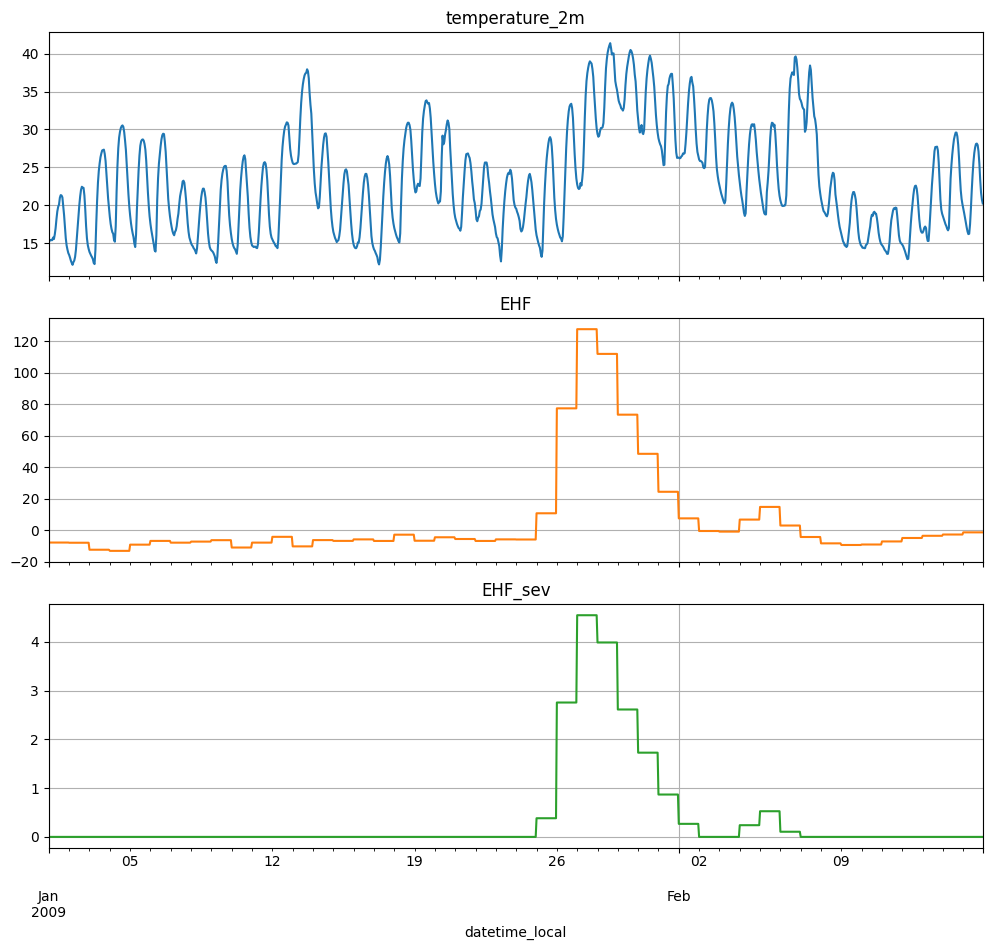

In [28]:
plot_time_slice(temp_1958_2024_df, '2009-01-01', '2009-02-15', ['temperature_2m', 'EHF', 'EHF_sev'], 
                datetime_type='local', subplots=True)

We spesifically choosed this interval and plotted `EHF and EHF_sev` values for quick simple validation of calculations and derivations. Because this spesific heatwave event and interval are also used in CAWCR report. So, we can see that our calculations and plots are match with report's.

In [ ]:
temp_1958_2024_df.to_csv('data/processed/temperature_1958_2024.csv', index=True, index_label="datetime_utc")

# References

Nairn, J., & Fawcett, R. (2013).
Defining heatwaves: Heatwave defined as a heat-impact event servicing all community and business sectors in Australia.
CAWCR Technical Report No. 060, CSIRO & Australian Bureau of Meteorology.
→ Primary source for EHI_sig, EHI_accl, EHF, and severity logic.

Bureau of Meteorology (BoM).
Heatwave Knowledge Centre – What is a heatwave?
https://www.bom.gov.au/resources/learn-and-explore/heatwave-knowledge-centre/what-is-a-heatwave

→ Operational definition and public-facing explanation used by BoM.

Bureau of Meteorology (2023).
Heatwave Service Level Specification – Season 2023–2024.
Australian Government, Bureau of Meteorology.
→ Confirms continued operational use of the EHF-based framework, and source for severity classes intervals.

Open-Meteo Archive API.
https://archive-api.open-meteo.com

→ Source of historical hourly temperature data used in this analysis.

# Bottom